In [1]:
import pandas as pd     # 数据表
import numpy as np     # 数组
import re     # 正则表达式
import jieba     # 中文分词
import matplotlib.pyplot as plt     # 画图
from gensim.models import Word2Vec     # 训练词嵌入模型
# import gensim.downloader as api     # 导入云端的已训练好的词向量
from gensim.models import KeyedVectors     # 加载自己本地个性化的已训练好的词向量
from sklearn.metrics.pairwise import cosine_similarity     # 计算向量之间的余弦相似度
from sklearn.decomposition import PCA     # 语义空间降维，用于展示词语在二维空间的相对位置

In [2]:
df = pd.read_excel('五年级.xlsx').astype(str)
df[:20]

,序号,年级,作文题目,作文id,作文标题,开头score,结尾score,审题score,立意score,详略score,条理score,选材score,想象score,思想score
0,1,5,读后感,696,智慧与谋略的交织,7.25,8.7,10.0,9.25,nan,9.5,nan,nan,9.2
1,2,5,读后感,696,《三国演义》有感,9.0,8.7,6.59,7.9,nan,9.0,nan,nan,9.2
2,3,5,读后感,716,智慧与权谋的交织,7.0,9.44,8.0,7.5,nan,9.0,nan,nan,9.5
3,4,5,神奇的探险之旅,724,雨林探险,8.25,6.2,9.085,7.95,9.0,nan,nan,8.7,nan
4,5,5,漫画的启示,726,等着乘凉,8.0,8.4,9.6,8.8,nan,9.0,nan,nan,nan
5,6,5,那一刻，我长大了,692,那一刻，我长大了,9.25,6.5,9.565,8.2,9.0,nan,nan,nan,nan
6,7,5,汉字研究报告,698,关于街头用字不规范现象的研究报告,nan,nan,6.215,nan,nan,8.5,nan,nan,nan
7,8,5,汉字研究报告,698,关于街头用字不规范现象的研究报告,nan,nan,9.84,nan,nan,9.5,nan,nan,nan
8,9,5,读后感,696,智慧与谋略的交织,7.25,6.4,8.665,8.8,nan,8.5,nan,nan,9.2
9,10,5,读后感,696,智慧与谋略的交织,7.0,8.5,9.6,9.1,nan,9.5,nan,nan,9.5


In [3]:
def remove_nums(text):
    nonums = re.sub('[^\u4e00-\u9fa5]+', '', text)
    return nonums
test = df['作文标题'][8]
remove_nums(test)

'智慧与谋略的交织'

In [4]:
# 加载中文停用词词典，可个性化设置
stopwords = open('stopwords.txt', encoding = 'utf-8').read()

def clean_text(text):
    words = jieba.lcut(text)
    words = [w for w in words if w not in stopwords]
    return ' '.join(words)
test = df['作文标题'][8]
clean_text(test)

Building prefix dict from the default dictionary ...
Loading model from cache /var/folders/kk/ylyfvmrj6zv853wrvp3s_0180000gn/T/jieba.cache
Loading model cost 0.345 seconds.
Prefix dict has been built successfully.


'智慧 谋略 交织'

In [5]:
df['作文标题分词'] = df['作文标题'].apply(remove_nums)
df['作文标题分词'] = df['作文标题分词'].apply(clean_text)
df.head()

,序号,年级,作文题目,作文id,作文标题,开头score,结尾score,审题score,立意score,详略score,条理score,选材score,想象score,思想score,作文标题分词
0,1,5,读后感,696,智慧与谋略的交织,7.25,8.7,10.0,9.25,nan,9.5,nan,nan,9.2,智慧 谋略 交织
1,2,5,读后感,696,《三国演义》有感,9.0,8.7,6.59,7.9,nan,9.0,nan,nan,9.2,三国演义 有感
2,3,5,读后感,716,智慧与权谋的交织,7.0,9.44,8.0,7.5,nan,9.0,nan,nan,9.5,智慧 权谋 交织
3,4,5,神奇的探险之旅,724,雨林探险,8.25,6.2,9.085,7.95,9.0,nan,nan,8.7,nan,雨林 探险
4,5,5,漫画的启示,726,等着乘凉,8.0,8.4,9.6,8.8,nan,9.0,nan,nan,nan,乘凉


In [6]:
import pandas as pd #数据表
import numpy as np #数组运算
import nltk #英文语料处理
import re #正则表达式（用于数据清洗）
import matplotlib.pyplot as plt #画图
from wordcloud import WordCloud #词云图
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import TweetTokenizer
from sklearn.feature_extraction.text import CountVectorizer

In [7]:
text=list(df['作文标题分词'])[:100]
text=" ".join(text)
lemmatizer=WordNetLemmatizer()
#转换为小写
text=text.lower()
#移除URL
text=re.sub(r'http\S+','',text)
text
#初始化CounVectorizer
vectorizer=CountVectorizer()
#将文本数据转换为词袋特征矩阵
X=vectorizer.fit_transform(df['作文标题分词'])
#展示特征矩阵的形状
print('词袋特征矩阵的形状:',X.shape)
#展示词袋模型中的所有特征词
print('特征词列表:',vectorizer.get_feature_names_out()[:20])

词袋特征矩阵的形状: (56421, 5180)
特征词列表: ['一丝不苟' '一个' '一代' '一件' '一位' '一分收获' '一分耕耘' '一切都是' '一刻' '一发' '一口' '一只' '一向'
 '一国' '一场' '一堂' '一声' '一处' '一家人' '一封']


In [8]:
#获取词汇表
feature_words=vectorizer.get_feature_names_out()
#计算词频
word_freq=dict(zip(feature_words,X.sum(axis=0).A1))

In [9]:
sorted(word_freq.items(),key=lambda X: X[1],reverse=True)
items = list(word_freq.items())
items.sort(key=lambda x:x[1], reverse=True)
for i in range(100):
    word, count = items[i]
    print("{0:<100}{1:>5}".format(word,count))
print ('已统计数量排前100的词')

研究                                                                                                   6311
报告                                                                                                   6239
探险                                                                                                   6218
智慧                                                                                                   6195
规范                                                                                                   6030
街头                                                                                                   5986
交织                                                                                                   5985
用字                                                                                                   5984
现象                                                                                                   5291
谋略                                            

In [10]:
import matplotlib.pyplot as plt
from matplotlib import font_manager
 
#for font in font_manager.fontManager.ttflist:
    # 查看字体名以及对应的字体文件名
   # print(font.name, '-', font.fname)

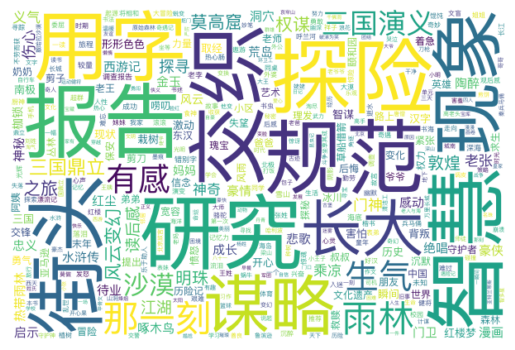

In [11]:
# 根据词袋模型分析结果绘制词云图
from wordcloud import WordCloud
import matplotlib.pyplot as plt 

wordcloud = WordCloud(
    font_path='/System/Library/Fonts/PingFang.ttc',  # 指定中文字体文件路径
    background_color='white',  # 设置背景颜色
    width=600,
    height=400,
    max_words=400,  # 设置最大显示的词数
    max_font_size=100  # 设置字体最大值
).generate_from_frequencies(word_freq)

# 显示词云图
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.savefig('wordcloud_五年级作文标题.png', dpi=300)
plt.show()

In [12]:
from gensim.test.utils import common_texts
common_texts

[['human', 'interface', 'computer'],
 ['survey', 'user', 'computer', 'system', 'response', 'time'],
 ['eps', 'user', 'interface', 'system'],
 ['system', 'human', 'system', 'eps'],
 ['user', 'response', 'time'],
 ['trees'],
 ['graph', 'trees'],
 ['graph', 'minors', 'trees'],
 ['graph', 'minors', 'survey']]

In [13]:
corpus=df['作文标题分词'].apply(lambda X: X.split()).tolist()#切分词语
for document in corpus[:10]:
    print(document[:20])

['智慧', '谋略', '交织']
['三国演义', '有感']
['智慧', '权谋', '交织']
['雨林', '探险']
['乘凉']
['那一刻', '长大']
['街头', '用字', '规范', '现象', '研究', '报告']
['街头', '用字', '规范', '现象', '研究', '报告']
['智慧', '谋略', '交织']
['智慧', '谋略', '交织']


In [14]:
#训练词嵌入模型
from gensim.models import Word2Vec
corpus=df['作文标题分词'].apply(lambda X: X.split()).tolist()#切分词语
model=Word2Vec(
    corpus, #训练语料
    window=5,#训练算法考虑的当前词语与预测词语在一个句子中的最大距离（窗口大小）
    vector_size=300,#自定义训练向量维度
    min_count=1,#忽略所有总频数低于这个值的词语
    #workers=4,#用于训练的线程数
    epochs=5)#迭代

#保存训练好的模型
model.save('word2vec_五年级作文标题.model')

In [15]:
word_list=model.wv.index_to_key#获取词汇表
word_vectors=model.wv[word_list]#获取词向量

#打印词汇表和对应的词向量
for word,vector in list(zip(word_list,word_vectors))[:5]:
    print(f'{word}:{vector}'[:20])

研究:[-3.95634174e-01 
报告:[-0.53754526  0.8
探险:[-3.31950337e-01 
智慧:[ 3.46127421e-01 
规范:[-0.3432562   0.5


In [16]:
#检查嵌入模型中任意两个词向量的余弦相似度，即语义接近性
#余弦相似度的取值介于[-1，1]之间，-1表示语义完全相反，1表示语义完全相同，0表示毫无关系
#model.sv.similarity这个函数与np.dot(vector1,vector2)/(np.linalg.norm(vector1)*np.linalg.norm(vector2))输出的结果一样
print(model.wv.similarity('研究', '报告'))
print(model.wv.similarity('研究', '探险'))
print(model.wv.similarity('研究', '智慧'))
print(model.wv.similarity('报告', '探险'))
print(model.wv.similarity('报告', '智慧'))
print(model.wv.similarity('探险', '智慧'))

0.92062426
0.48279324
0.32619146
0.49792984
0.25223637
0.23201123


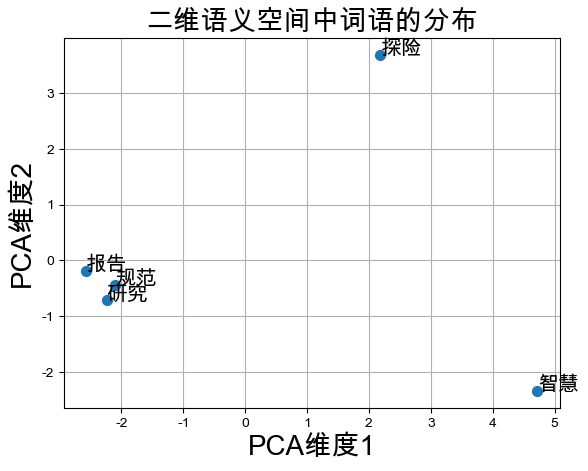

In [17]:
# 可视化

words = ['研究', '报告', '探险', '智慧','规范']
vectors = [model.wv[word] for word in words]

from sklearn.decomposition import PCA     # 语义空间降维，用于展示词语在二维空间的相对位置

# 使用PCA进行降维
pca = PCA(n_components = 2)
pca_result = pca.fit_transform(vectors)

import matplotlib.pyplot as plt     # 画图

# 绘制四个词语在二维空间的相对位置
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False
plt.figure()

# 取PCA降维结果中所有行的第一列和第二列数据绘制散点图，设置点的大小为50
plt.scatter(pca_result[:, 0], pca_result[:, 1], s = 50)

for i, word in enumerate(words):
    plt.annotate(word, (pca_result[i, 0], pca_result[i, 1]), fontsize = 15)

plt.xlabel('PCA维度1', fontsize = 20)
plt.ylabel('PCA维度2', fontsize = 20)
plt.title('二维语义空间中词语的分布', fontsize = 20)
plt.grid(True)
plt.show()

In [18]:
import gensim
from gensim import corpora
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import warnings
warnings.filterwarnings('ignore')  # To ignore all warnings that arise here to enhance clarity

from gensim.models.coherencemodel import CoherenceModel
from gensim.models.ldamodel import LdaModel

In [19]:
from gensim.models import Word2Vec
txt=df['作文标题分词'].apply(lambda X: X.split()).tolist()#切分词语

In [20]:
dictionary = corpora.Dictionary(txt)  # 构建词典
corpus = [dictionary.doc2bow(text) for text in txt]  #表示为第几个单词出现了几次

In [21]:
ldamodel = LdaModel(corpus, num_topics=10, id2word = dictionary, passes=30,random_state = 1)   #分为10个主题
num_topics=10
print(ldamodel.print_topics(num_topics=num_topics, num_words=15)[:20])  #每个主题输出15个单词

[(0, '0.124*"江湖" + 0.114*"义气" + 0.075*"豪侠" + 0.042*"水浒传" + 0.036*"妈妈" + 0.028*"背叛" + 0.028*"开心" + 0.026*"李" + 0.020*"爱" + 0.016*"唠叨" + 0.013*"英雄" + 0.012*"深海" + 0.011*"勇气" + 0.010*"老师" + 0.009*"成功"'), (1, '0.210*"长大" + 0.209*"那一刻" + 0.155*"有感" + 0.147*"读" + 0.104*"三国演义" + 0.021*"西游记" + 0.020*"成长" + 0.018*"水浒传" + 0.010*"瞬间" + 0.006*"求生" + 0.004*"字" + 0.003*"光明" + 0.003*"寻踪" + 0.003*"韵" + 0.003*"墨痕"'), (2, '0.372*"探险" + 0.325*"雨林" + 0.042*"神秘" + 0.029*"荒岛" + 0.022*"南极" + 0.011*"奶奶" + 0.010*"愤怒" + 0.009*"爷爷" + 0.008*"交锋" + 0.007*"失望" + 0.006*"海底" + 0.005*"阿姨" + 0.005*"亚马逊" + 0.005*"沉醉" + 0.005*"雪山"'), (3, '0.160*"研究" + 0.159*"报告" + 0.156*"规范" + 0.154*"用字" + 0.154*"街头" + 0.136*"现象" + 0.029*"门神" + 0.025*"老张" + 0.003*"汉字" + 0.002*"楷书" + 0.001*"海洋" + 0.001*"老妈" + 0.001*"原始森林" + 0.000*"侠义" + 0.000*"水浒"'), (4, '0.512*"生气" + 0.078*"陶醉" + 0.028*"后悔" + 0.028*"取经" + 0.028*"紧张" + 0.024*"路上" + 0.021*"颐和园" + 0.016*"信念" + 0.014*"救赎" + 0.012*"调查报告" + 0.011*"东汉" + 0.011*"末年" + 0.011*"错别字" + 0.006*"豪杰" + 

In [22]:
#计算困惑度
def perplexity(num_topics):
    ldamodel = LdaModel(corpus, num_topics=num_topics, id2word = dictionary, passes=30)
    print(ldamodel.print_topics(num_topics=num_topics, num_words=15))
    print(ldamodel.log_perplexity(corpus))
    return ldamodel.log_perplexity(corpus)

In [23]:
#计算coherence
def coherence(num_topics):
    ldamodel = LdaModel(corpus, num_topics=num_topics, id2word = dictionary, passes=30,random_state = 1)
    print(ldamodel.print_topics(num_topics=num_topics, num_words=10))
    ldacm = CoherenceModel(model=ldamodel, texts=txt, dictionary=dictionary, coherence='c_v')
    print(ldacm.get_coherence())
    return ldacm.get_coherence()

[(0, '0.042*"智慧" + 0.041*"交织" + 0.040*"研究" + 0.039*"报告" + 0.039*"规范" + 0.038*"探险" + 0.038*"用字" + 0.038*"街头" + 0.034*"现象" + 0.028*"谋略"')]
0.5912450689270818
[(0, '0.078*"研究" + 0.078*"报告" + 0.076*"规范" + 0.076*"用字" + 0.076*"街头" + 0.067*"现象" + 0.047*"哭" + 0.041*"生气" + 0.027*"沙漠" + 0.027*"三国鼎立"'), (1, '0.084*"智慧" + 0.082*"交织" + 0.078*"探险" + 0.057*"谋略" + 0.051*"长大" + 0.051*"那一刻" + 0.045*"雨林" + 0.037*"有感" + 0.036*"读" + 0.032*"三国演义"')]
0.5983965430733587
[(0, '0.088*"研究" + 0.087*"报告" + 0.086*"规范" + 0.085*"用字" + 0.085*"街头" + 0.074*"现象" + 0.053*"哭" + 0.031*"沙漠" + 0.030*"三国鼎立" + 0.027*"风云变幻"'), (1, '0.125*"智慧" + 0.122*"交织" + 0.085*"谋略" + 0.075*"长大" + 0.075*"那一刻" + 0.056*"有感" + 0.053*"读" + 0.047*"三国演义" + 0.035*"权谋" + 0.027*"读后感"'), (2, '0.180*"探险" + 0.104*"雨林" + 0.096*"生气" + 0.053*"之旅" + 0.028*"神奇" + 0.019*"洞穴" + 0.018*"热带雨林" + 0.018*"门卫" + 0.014*"神秘" + 0.010*"王"')]
0.5928452402350889
[(0, '0.127*"哭" + 0.073*"沙漠" + 0.072*"三国鼎立" + 0.065*"风云变幻" + 0.065*"莫高窟" + 0.057*"明珠" + 0.055*"敦煌" + 0.050*"探寻" + 

0.6012581794173969
[(0, '0.177*"风云变幻" + 0.168*"三国鼎立" + 0.142*"江湖" + 0.085*"义气" + 0.056*"豪侠" + 0.054*"忠义" + 0.053*"豪情" + 0.049*"悲歌" + 0.021*"背叛" + 0.021*"开心"'), (1, '0.268*"有感" + 0.254*"读" + 0.181*"三国演义" + 0.048*"水浒传" + 0.037*"西游记" + 0.012*"世界" + 0.011*"中国" + 0.011*"求生" + 0.010*"文化遗产" + 0.009*"深海"'), (2, '0.310*"探险" + 0.291*"雨林" + 0.267*"生气" + 0.038*"神秘" + 0.010*"奶奶" + 0.008*"爷爷" + 0.005*"亚马逊" + 0.004*"刘" + 0.003*"难过" + 0.003*"手机"'), (3, '0.160*"研究" + 0.159*"报告" + 0.156*"规范" + 0.155*"用字" + 0.154*"街头" + 0.136*"现象" + 0.025*"老张" + 0.023*"门神" + 0.004*"汉字" + 0.003*"冒险"'), (4, '0.112*"成长" + 0.106*"风云" + 0.086*"三国鼎立" + 0.065*"变化" + 0.056*"瞬间" + 0.053*"后悔" + 0.052*"紧张" + 0.028*"守护者" + 0.025*"风雨" + 0.025*"字"'), (5, '0.172*"长大" + 0.171*"那一刻" + 0.165*"哭" + 0.095*"沙漠" + 0.084*"莫高窟" + 0.074*"明珠" + 0.071*"敦煌" + 0.065*"探寻" + 0.017*"感动" + 0.011*"害怕"'), (6, '0.076*"形形色色" + 0.066*"三国" + 0.055*"历史" + 0.044*"现状" + 0.041*"提出" + 0.037*"历险记" + 0.029*"弟弟" + 0.028*"愤怒" + 0.028*"爸爸" + 0.022*"老师"'), (7, '0.198*"探

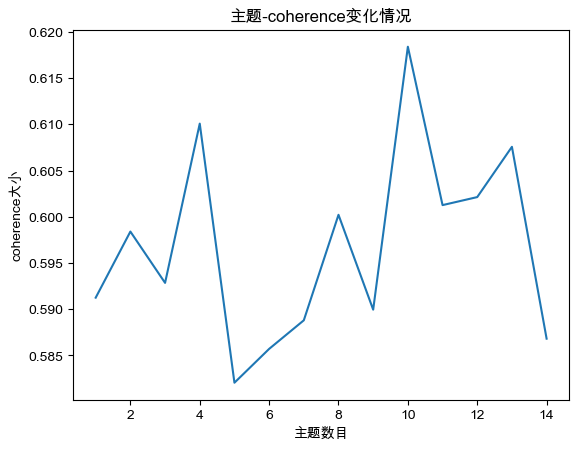

In [24]:
# 绘制困惑度折线图
x = range(1,15)
# z = [perplexity(i) for i in x]
y = [coherence(i) for i in x]
plt.plot(x, y)
plt.xlabel('主题数目')
plt.ylabel('coherence大小')
plt.rcParams['font.sans-serif']=['Arial Unicode MS']
matplotlib.rcParams['axes.unicode_minus']=False
plt.title('主题-coherence变化情况')
plt.show()

In [25]:
lda = LdaModel(corpus=corpus, id2word=dictionary, num_topics=5, passes = 30,random_state=1)
topic_list=lda.print_topics()
print(topic_list[:20])

[(0, '0.162*"哭" + 0.047*"江湖" + 0.046*"有感" + 0.041*"乘凉" + 0.041*"读" + 0.040*"义气" + 0.029*"水浒传" + 0.026*"豪侠" + 0.024*"西游记" + 0.017*"金玉"'), (1, '0.158*"智慧" + 0.154*"交织" + 0.107*"谋略" + 0.095*"长大" + 0.094*"那一刻" + 0.060*"三国演义" + 0.044*"有感" + 0.044*"权谋" + 0.044*"读" + 0.034*"读后感"'), (2, '0.246*"探险" + 0.143*"雨林" + 0.131*"生气" + 0.073*"之旅" + 0.039*"神奇" + 0.026*"洞穴" + 0.025*"热带雨林" + 0.022*"啄木鸟" + 0.019*"神秘" + 0.018*"待业"'), (3, '0.138*"研究" + 0.137*"报告" + 0.134*"规范" + 0.133*"用字" + 0.133*"街头" + 0.117*"现象" + 0.025*"门神" + 0.022*"老张" + 0.015*"忠义" + 0.013*"门卫"'), (4, '0.100*"沙漠" + 0.098*"三国鼎立" + 0.089*"风云变幻" + 0.089*"莫高窟" + 0.078*"明珠" + 0.075*"敦煌" + 0.068*"探寻" + 0.036*"笑" + 0.023*"陶醉" + 0.017*"风云"')]


In [26]:
result_list =[]
for i in lda.get_document_topics(corpus)[:]:
    listj=[]
    for j in i:
        listj.append(j[1])
    bz=listj.index(max(listj))
    result_list.append(i[bz][0])
print(result_list[:20])

[1, 1, 1, 2, 0, 1, 3, 3, 1, 1, 2, 1, 0, 2, 0, 0, 1, 4, 1, 1]


In [27]:
import pyLDAvis.gensim
pyLDAvis.enable_notebook()
data = pyLDAvis.gensim.prepare(lda, corpus, dictionary)
pyLDAvis.save_html(data, '五年级作文标题.html')